In [51]:
# -*- coding: utf-8 -*-
import logging
from pathlib import Path
import os
import pandas as pd
import numpy as np

## Source ID dataframe from existing dat files

In [52]:
current_dir =  Path(globals()['_dh'][0])
try:
    os.mkdir(os.path.join(current_dir, '1.0-jrb-external-data-exploration'))
except:
    print("Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.")

Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.


We have to build a dataframe with the source id information of available .dat files, and we will compare this to the new dataset.

In [53]:
project_dir =  Path(globals()['_dh'][0]).parent
    
# Loading training, test and validation sets.

sdss_data_path = os.path.join(project_dir, r'data\raw\sdss_dat_files')
dat_sid_info = pd.DataFrame()

for folder in os.listdir(sdss_data_path):
    folder_path = os.path.join(sdss_data_path, folder)
    for filename in os.listdir(folder_path):
        if filename.startswith('boss'):
            csv_path = os.path.join(folder_path, filename)
            boss_set = pd.read_csv(csv_path, usecols=['catalogid', 'PLATE', 'MJD', 'FIBERID', 'sdss_name', 'source_id'])
            dat_sid_info = dat_sid_info.append(boss_set)
dat_sid_info.reset_index(drop=True, inplace=True)

C:\Users\jotab\AppData\Local\Temp\ipykernel_10384\3726468483.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dat_sid_info = dat_sid_info.append(boss_set)
C:\Users\jotab\AppData\Local\Temp\ipykernel_10384\3726468483.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dat_sid_info = dat_sid_info.append(boss_set)
C:\Users\jotab\AppData\Local\Temp\ipykernel_10384\3726468483.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dat_sid_info = dat_sid_info.append(boss_set)
C:\Users\jotab\AppData\Local\Temp\ipykernel_10384\3726468483.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dat_sid_info = dat_sid_info.append(boss_set)
C:\Users

In [54]:
dat_sid_info

,catalogid,sdss_name,source_id,PLATE,MJD,FIBERID
0,4402820199,SDSSJ000233.81+270635.1,2853906438483521792,15004,59165,70
1,4402818262,SDSSJ000247.16+263833.7,2853874891950543872,15004,59165,80
2,4402833095,SDSSJ000855.76+270609.0,2853763295814123264,15004,59165,185
3,4400718283,SDSSJ001155.43+252337.6,2850276740147442176,15004,59165,289
4,4400711835,SDSSJ000532.94+255234.0,2850214759473921408,15004,59165,387
...,...,...,...,...,...,...
52378,4268579309,SDSSJ185244.26+590129.1,2155352131166620160,15387,59386,444
52379,4268562093,SDSSJ184946.24+583517.3,2154565778490346368,15387,59386,445
52380,4269039854,SDSSJ184554.31+581147.1,2154515132235970048,15387,59386,463
52381,4268561022,SDSSJ184634.52+580859.1,2154467161745440640,15387,59386,464


## Crossmatch information

Now we should extract the information from the crossmatch search with gaia.

In [55]:
# Loading crossmatch information

crossmatch_path = os.path.join(project_dir, r'data\external\crossmatch')
cm_info = pd.DataFrame()

for filename in os.listdir(crossmatch_path):
    if not (filename.endswith('ipynb') or filename.endswith('da')):
        csv_path = os.path.join(crossmatch_path, filename)
        star_set = pd.read_csv(csv_path, usecols=['PLATEID','MJDID','FIBERID','THING_ID', 'source_id'])
        star_set['classID'] = filename.split('_')[-1]
        cm_info = cm_info.append(star_set)
cm_info.reset_index(drop=True, inplace=True)

C:\Users\jotab\AppData\Local\Temp\ipykernel_10384\1045930882.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  cm_info = cm_info.append(star_set)
C:\Users\jotab\AppData\Local\Temp\ipykernel_10384\1045930882.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  cm_info = cm_info.append(star_set)
C:\Users\jotab\AppData\Local\Temp\ipykernel_10384\1045930882.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  cm_info = cm_info.append(star_set)
C:\Users\jotab\AppData\Local\Temp\ipykernel_10384\1045930882.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  cm_info = cm_info.append(star_set)
C:\Users\jotab\AppData\Local\Temp\ipykernel_1038

In [56]:
cm_info

,PLATEID,MJDID,FIBERID,THING_ID,source_id,classID
0,6290.0,56238.0,770.0,329176691.0,1876751655807530752,cv
1,8227.0,57427.0,629.0,493785950.0,1571768231438756864,cv
2,7117.0,56685.0,854.0,524628776.0,1566956008344163456,cv
3,4999.0,55721.0,420.0,390531345.0,1333882980892489472,cv
4,4200.0,55499.0,122.0,83907657.0,2678566696432062336,cv
...,...,...,...,...,...,...
1700,6402.0,56334.0,614.0,357580047.0,4019646766906456448,dz
1701,5888.0,56041.0,474.0,270361011.0,3983562478910025728,dz
1702,4355.0,55533.0,770.0,63723465.0,2449345460075810048,dz
1703,4638.0,55956.0,540.0,449441017.0,814515018401000064,dz


We need to build a routine which will compare objects which are currently on our catalog and those who arent

In [57]:
dat_sid = dat_sid_info['source_id'].unique()
counter = 0
collisions = list()

for sid, classid in zip(cm_info['source_id'], cm_info['classID']):
   if sid in dat_sid:
      #counter += 1
      #print('found collision for element {}, number {} and type  {}'.format(sid, counter, classid))
      collisions.append((sid, classid, (dat_sid_info[dat_sid_info['source_id'] == sid]['catalogid']).iloc[0]))
print(len(collisions))

138


In [58]:
collisions

[(1777232423131443840, 'cv', 4383253183),
 (2510205490257050496, 'cv', 4399911413),
 (581110831791334400, 'cv', 4545208616),
 (2494386992562185088, 'cv', 4375881540),
 (1558322303741820928, 'cv', 4351662016),
 (2500552912036565120, 'cv', 4401862688),
 (2642699218384434432, 'cv', 4371155462),
 (577877683490889728, 'cv', 4545159216),
 (919046658301858048, 'cv', 4555251014),
 (2806802123399581056, 'cv', 4400901787),
 (2500552912036565120, 'cv', 4401862688),
 (1176468611268115200, 'cv', 4601012187),
 (2500552912036565120, 'cv', 4401862688),
 (751777469035821312, 'cv', 4597584648),
 (1778468682222798080, 'cv', 4383285955),
 (3952276665815698560, 'cv', 4599536987),
 (3851194924037285760, 'da+ms', 4592988582),
 (3838090287327030144, 'da+ms', 4570519715),
 (1388193009853778304, 'da+ms', 4350084696),
 (3981004327669198336, 'da+ms', 4595982742),
 (919977631116723584, 'da+ms', 4555383292),
 (896190212446380416, 'da+ms', 4553889616),
 (1547829561199713280, 'da+ms', 4351893403),
 (58118504882609497

## Working with the repeated elements

for the 138 repeated elements we will determine if they already belong to some set (train, test or validation), or if they dont.

In [59]:
project_dir =  Path(globals()['_dh'][0]).parent
file_path =  'data/interim/clean_labels.csv'


clean_labels_df = pd.read_csv(os.path.join(project_dir, file_path))
clean_labels_df

,Classification,DB ID,Data Quality,File Name,MJD,Target ID
0,WDA,21899,OK,spec-15249-59265-04601916346-21899.png,59265,4601916346
1,sdX,23360,BLEND,spec-15301-59338-04602344336-23360.png,59338,4602344336
2,WDA,18900,SNR,spec-15113-59217-04538755416-18900.png,59217,4538755416
3,WDA,18575,OK,spec-15086-59267-04474143209-18575.png,59267,4474143209
4,WD,20528,SNR,spec-15198-59269-04351438385-20528.png,59269,4351438385
...,...,...,...,...,...,...
35248,WDA,15895,SNR,spec-15011-59222-04399876473-15895.png,59222,4399876473
35249,WDA,20605,OK,spec-15200-59324-04589320996-20605.png,59324,4589320996
35250,WDA,19388,OK,spec-15193-59243-04594923329-19388.png,59243,4594923329
35251,DUNNO,19161,SNR,spec-15121-59212-04342114705-19161.png,59212,4342114705


In [60]:
clean_list = clean_labels_df['Target ID'].unique()
counter = 0

for element in collisions:
    sid, classid, tid = element
    if tid in clean_list:
        counter += 1
        #print(clean_labels_df[clean_labels_df['Target ID'] == tid], classid, counter)

In [61]:
pd.set_option("display.max_colwidth", -1)

train_csv_path = os.path.join(project_dir, r'data\processed\train_set.csv')
train_set = pd.read_csv (train_csv_path)
train_set

C:\Users\jotab\AppData\Local\Temp\ipykernel_10384\360410858.py:1: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option("display.max_colwidth", -1)


,filename,classID
0,wd\SDSSJ075753.29+375354.7_15020-59284-0065_4555413565.dat,WDA
1,cb_uvex2\SDSSJ144213.72+031631.5_15306-59289-0275_4600810637.dat,WDA
2,wd\SDSSJ113408.31+592846.6_15235-59346-0090_4359649477.dat,WDZ
3,cb_uvex2\SDSSJ083412.81+252544.5_15060-59222-0327_4554916407.dat,WDA
4,wd\SDSSJ015824.04-003510.8_15013-59165-0439_4375885332.dat,WDA
...,...,...
3361,wd\SDSSJ213032.52-014234.3_15027-59159-0287_4367790152.dat,WDA
3362,wd\SDSSJ162433.28+642346.6_15347-59301-0160_4347445705.dat,WDZ
3363,wd\SDSSJ081656.15+204945.8_15052-59229-0080_4546454863.dat,WDB
3364,wd\SDSSJ080636.19+194548.2_15052-59229-0004_4546222044.dat,WDA


In [62]:
test_csv_path = os.path.join(project_dir, r'data\processed\test_set.csv')
test_set = pd.read_csv (test_csv_path)
test_set

,filename,classID
0,wd\SDSSJ113118.07+573937.5_15235-59254-0390_4359800251.dat,WDA
1,wd\SDSSJ124120.58+270920.8_15250-59267-0361_4601944809.dat,WDC
2,wd\SDSSJ153329.20+070028.9_15272-59305-0079_5171003069.dat,WDC
3,cb_uvex2\SDSSJ160423.55+540014.3_15330-59324-0097_4346419866.dat,sdX
4,wd\SDSSJ061552.66+030908.1_15137-59214-0046_4522376024.dat,WDA
...,...,...
1119,wd\SDSSJ052912.12-074651.6_15111-59218-0349_4416246845.dat,WDA
1120,wd\SDSSJ013824.57+003339.4_15012-59166-0307_4399906650.dat,WDA
1121,wd\SDSSJ212117.93-011307.5_15027-59159-0474_4367747398.dat,WDA
1122,cb_uvex2\SDSSJ125739.79+580414.1_15348-59329-0057_4351324270.dat,WD+MS


In [63]:
valid_csv_path = os.path.join(project_dir, r'data\processed\valid_set.csv')
valid_set = pd.read_csv(valid_csv_path)
valid_set

,filename,classID
0,wd\SDSSJ122257.58+300242.6_15249-59265-0059_4601920409.dat,WDA
1,wd\SDSSJ012606.08+144045.9_15010-59199-0313_4401110588.dat,WDA
2,wd\SDSSJ090803.30+513632.7_15174-59232-0014_4360830340.dat,WDZ
3,wd\SDSSJ015221.11-003037.7_15013-59165-0159_4375865746.dat,WDA
4,wd\SDSSJ084824.88+020918.5_15146-59206-0321_4545149860.dat,WDA
...,...,...
1118,wd\SDSSJ083628.20+354649.6_15062-59227-0336_4555706551.dat,WDA
1119,wd\SDSSJ063256.89+171629.5_15229-59303-0400_4537378243.dat,WDA
1120,wd\SDSSJ164122.52+393649.2_15309-59312-0293_5191881977.dat,WDA
1121,wd\SDSSJ075645.52+272747.8_15021-59165-0078_4554384693.dat,WDA


We will make new test, training and validation sets from the external data. For each element in collision, we will test if its already in some of the 3 already existing datasets, if any. For the elements not in collision, we will divide them in a strattified manner.

In [64]:
def filename_to_tid(filename_list):
    for index, filename in enumerate(filename_list):
        filename_list[index] = filename.split('_')[-1][:-4]
    return filename_list

train_list = filename_to_tid(train_set['filename'].to_list())
test_list = filename_to_tid(test_set['filename'].to_list())
valid_list = filename_to_tid(valid_set['filename'].to_list())

In [65]:
for element in collisions:
    sid, classid, tid = element
    if tid in train_list:
        print('element in train')
    if tid in test_list:
        print('test in train')
    if tid in valid_list:
        print('valid in train')

There seems to be no collisions with the train, test and validation sets! Great news! now we will create ext_train_set, ext_test_set and ext_valid_set.

## Exploring the external dataset: the wavelenght axis

In [66]:
import numpy as np
# Set up matplotlib
import matplotlib.pyplot as plt


from astropy.io import fits
from astropy.convolution import convolve, Box1DKernel

def extraction(fitfile):
    hdu  = fits.open(fitfile)
    data = hdu['COADD'].data
    w = 10**data['loglam']
    f = data['flux']*1e-17

    # Check if wavelenghts are considered in vacuum, addjust if necessary.
    h_data = hdu[0].header
    if (h_data['VACUUM']):
        w = w / (1.0 + 2.735182E-4 + 131.4182 / w ** 2 + 2.76249E8 / w ** 4)
    return w,f

def convolution(w,f, box=5):
    kernel = Box1DKernel(box)
    smoothed = convolve(f, kernel)
    return w,smoothed

In [67]:
fits_path = os.path.join(project_dir, r'data\external\fits_spectrums\bossdq\spec-03851-55302-0214.fits')

w,f = extraction(fits_path)
w, smoothed = convolution(w, f)

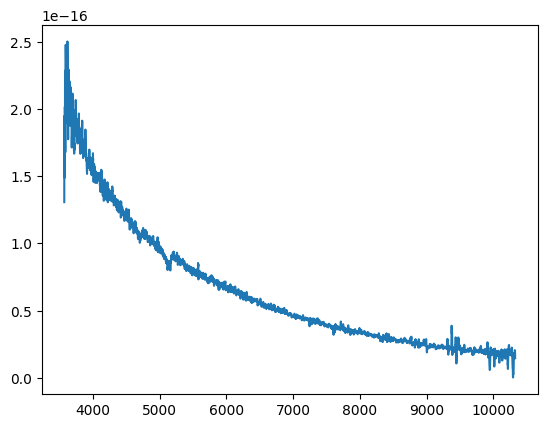

In [68]:
plt.plot(w, smoothed)

In [69]:
print(w, len(w))

[ 3572.5325  3573.3542  3574.1763 ... 10320.027  10322.396  10324.776 ] 4610


In [70]:
w[4200]

9396.813

In [71]:
dat_path = os.path.join(project_dir, r'data\raw\sdss_dat_files\100pc\SDSSJ000114.83+573308.3_15076-59207-0257_4291516873.dat')
sed = np.loadtxt(dat_path, unpack = True)
wavelength = sed[0,:]
flux = sed[1,:]
print(wavelength, len(wavelength))

[ 3565.956  3566.777  3567.599 ... 10391.558 10393.954 10396.352] 4648


In [72]:
dat_path = os.path.join(project_dir, r'data\raw\sdss_dat_files\cb_uvex3\SDSSJ074107.26+310612.8_15016-59146-0062_4551581537.dat')
sed = np.loadtxt(dat_path, unpack = True)
wavelength = sed[0,:]
flux = sed[1,:]
print(wavelength, len(wavelength))

[ 3565.956  3566.777  3567.599 ... 10391.558 10393.954 10396.352] 4648


In [73]:
wavelength = sed[0,48:-400]
flux = sed[1,48:-400]
print(wavelength, len(wavelength))

[3605.589 3606.418 3607.25  ... 9477.212 9479.393 9481.578] 4200


In [74]:
dat_path = os.path.join(project_dir, r'data\raw\sdss_dat_files\cb_uvex3\SDSSJ133448.14+374547.9_15299-59369-0406_4602877123.dat')
sed = np.loadtxt(dat_path, unpack = True)
base_wavelenght = sed[0,48:-400]
flux = sed[1,48:-400]
print(wavelength, len(wavelength))

[3605.589 3606.418 3607.25  ... 9477.212 9479.393 9481.578] 4200


Exploring the data above we can see that our original samples stored as dat files were probably interpolated to a common wavelenght when they were generated. On the other hand, we now need to interpolate our new external data so the flux values are taken at the same wavelenghts as the original samples.

## Defining train, test and validation sets

In [75]:
import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.features.build_features as bfs

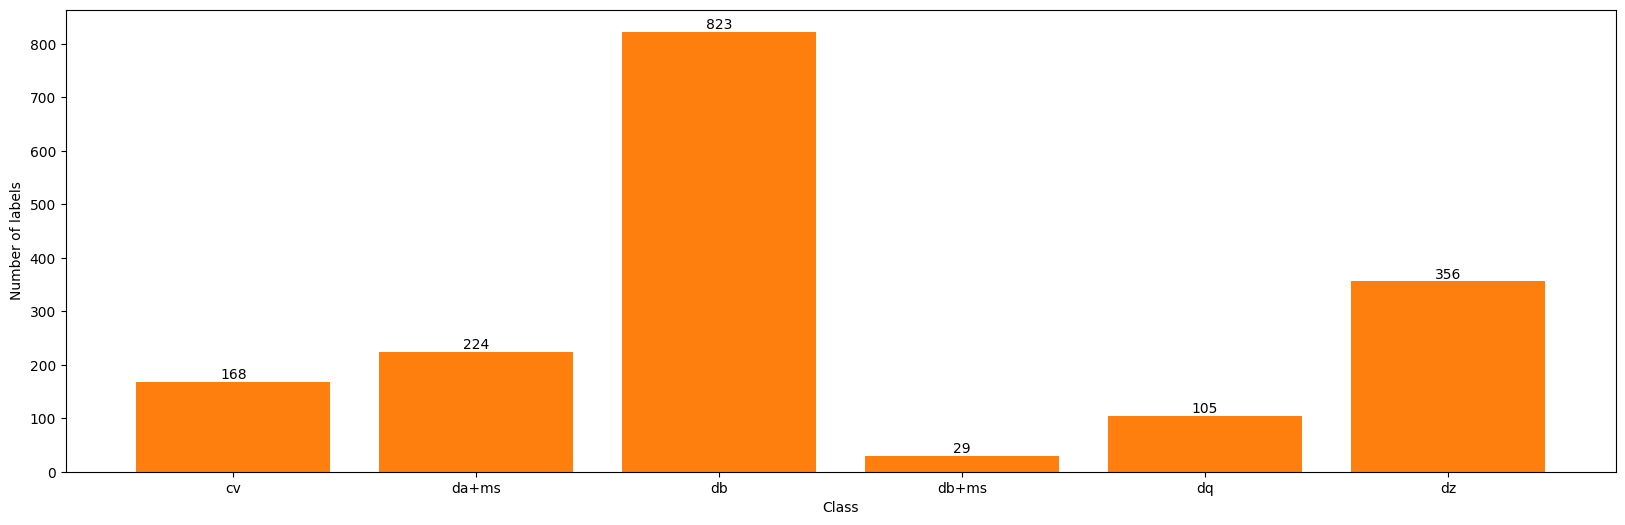

In [76]:
from collections import Counter

# Plot bar graph of labels

counter = Counter(cm_info['classID'])
star_class = counter.keys()
star_counts = counter.values()
indexes = np.arange(len(star_class))
width = 0.7

fig, ax = plt.subplots(figsize=(20,6))

ax.bar(indexes, star_counts, width)
bars = ax.bar(indexes, star_counts)
ax.bar_label(bars)

plt.xlabel('Class')
plt.ylabel('Number of labels')
plt.xticks(indexes, labels=star_class)
plt.show()

We will load the numpy matrices and decode de one hot encoding keys used to generate them:

In [77]:
train_label_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_train_label_matrix.npy'))
valid_label_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_valid_label_matrix.npy'))
train_spectrum_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_train_spectrum_matrix.npy'))
valid_spectrum_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_valid_spectrum_matrix.npy'))

In [78]:
import src.visualization.visualize as vsz

train_csv_path = os.path.join(project_dir, r'data\processed\train_set.csv')
train_set = pd.read_csv (train_csv_path)
ohe_dict = vsz.ohe_decoder(train_set['classID'], train_label_matrix)
star_class = vsz.sort_ohe(ohe_dict)

In [79]:
ohe_dict

{'WDA': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDZ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 'WDB': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 'WDO': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 'WD+MS': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WD': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'sdX': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 'WDH': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 'WDELM': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'WDC': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 'CV': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDQ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])}

In our external data dataframe, We will create a new column with the name folder and another with the class id in the right format. We will also fix the format of the fields.

In [80]:
cm_info = cm_info.astype({"PLATEID": 'int64', "MJDID": 'int64', "FIBERID" : 'int64', "THING_ID" : 'int64'})
cm_info

,PLATEID,MJDID,FIBERID,THING_ID,source_id,classID
0,6290,56238,770,329176691,1876751655807530752,cv
1,8227,57427,629,493785950,1571768231438756864,cv
2,7117,56685,854,524628776,1566956008344163456,cv
3,4999,55721,420,390531345,1333882980892489472,cv
4,4200,55499,122,83907657,2678566696432062336,cv
...,...,...,...,...,...,...
1700,6402,56334,614,357580047,4019646766906456448,dz
1701,5888,56041,474,270361011,3983562478910025728,dz
1702,4355,55533,770,63723465,2449345460075810048,dz
1703,4638,55956,540,449441017,814515018401000064,dz


Now we will create our strattified sets from the external data

In [81]:
ext_train_set, ext_test_set, ext_valid_set = bfs.make_stratified_sets(cm_info, train_set_size=0.6, validation_test_split=0.5)

In [82]:
ext_test_set

,PLATEID,MJDID,FIBERID,THING_ID,source_id,classID
979,4687,56338,324,450788175,816957652201967104,db
379,4831,55679,896,165613661,3895444662122848512,da+ms
846,7111,56741,998,550754557,1060633278870718720,db
741,6321,56449,384,478047038,1399113874736902656,db
57,7386,56769,764,477280410,834461538014044288,cv
...,...,...,...,...,...,...
235,3810,55531,70,128247855,3075901233451525888,da+ms
218,3670,55480,456,422139195,896190212446380416,da+ms
702,6681,56419,818,499972873,1572347051293826048,db
1004,5729,56598,520,498628904,1017448031249546624,db


Now we will define a function to create a numpy array from the spectrum data and one hot encode the data.

In [83]:
import statistics

In [84]:
ext_data_dict = { 'cv' : 'CV',  'da' : 'WDA', 'da+ms' : 'WD+MS', 'db+ms' : 'WD+MS', 'db' : 'WDB', 'dq' : 'WDQ', 'dz' : 'WDZ', 'wd' : 'WD'}

In [85]:
def zero_pad_str(final_len, my_str):
    """
    Appends zeros to the left side of str until reaching desired lenght
    """
    return (final_len - len(my_str)) * '0' + my_str if final_len > len(my_str) else my_str

def ext_data_processing_and_loading(ext_data_path, block_df, base_wavelenght, ohe_dict, ext_data_dict, normalize=False):
    """
    The following function takes a dataframe consisting of two columns: filename of .dat
    file and class ID, and returns numpy arrays consisting of the spectrum data matrix.

    This functions also does some flux data pre-processing, trimming the edges of the signal 
    and normalizing flux magnitud to 1 around 5847 [A] 

    Parameters
    ----------
    :sdss_data_path: path to folders where each subfolder contains .dat files.
    :block_df: dataframe with two columns, filenames and class id.
    :stars_enconding: dictionary with one hot encoding. 

    Returns
    -------
    :return: returns two numpy arrays, one for the spectrum data and one for the one hot encoded label data, 
    and the filename of spectrums with nan data which will be removed from the datasets.
    """ 
    to_remove = list()
    spectrum_matrix = np.empty((0,4200), float)
    label_ohe_matrix = np.empty((0,12), float)

    for _, row in block_df.iterrows(): 
        relative_path = 'boss' + row['classID'] + '\\' + 'spec-' + zero_pad_str(5, str(row['PLATEID'])) + '-' + str(row['MJDID']) + '-' + zero_pad_str(4, str(row['FIBERID'])) + '.fits'
        fits_path = os.path.join(ext_data_path, relative_path)
        w,f = extraction(fits_path)

        # Interpolation
        flux = np.interp(base_wavelenght, w, f)

        # we will not use data with nan elements or zero mean.
        flux_mean = statistics.mean(flux)
        if(np.isnan(flux).any() or np.isnan(w).any() or flux_mean == 0):
            to_remove.append(row['THING_ID'])
        else:
            # Normalize if required by user
            if normalize:
                flux = np.divide(flux, flux_mean)
            # append data
            spectrum_matrix = np.append(spectrum_matrix, np.transpose(flux[:, None]), axis=0)
            label_ohe_matrix = np.append(label_ohe_matrix, ohe_dict[ext_data_dict[row['classID']]].reshape(1, 12), axis=0)
    for element in to_remove:
        block_df.drop(block_df.index[block_df['THING_ID'] == element], inplace = True)
    return spectrum_matrix, label_ohe_matrix


# Define base wavelenght

dat_path = os.path.join(project_dir, r'data\raw\sdss_dat_files\cb_uvex3\SDSSJ133448.14+374547.9_15299-59369-0406_4602877123.dat')
sed = np.loadtxt(dat_path, unpack = True)
base_wavelenght = sed[0,48:-400]

In [86]:

dat_path = os.path.join(project_dir, r'data\raw\sdss_dat_files\cb_uvex3\SDSSJ133448.14+374547.9_15299-59369-0406_4602877123.dat')
sed = np.loadtxt(dat_path, unpack = True)
base_wavelenght = sed[0,48:-400]

In [87]:
# Call external pre processing function

ext_data_path = os.path.join(project_dir, r'data\external\fits_spectrums')
ext_train_spectrum_matrix, ext_train_label_matrix = ext_data_processing_and_loading(ext_data_path, ext_train_set, base_wavelenght, ohe_dict, ext_data_dict, normalize=True)
ext_valid_spectrum_matrix, ext_valid_label_matrix = ext_data_processing_and_loading(ext_data_path, ext_valid_set, base_wavelenght, ohe_dict, ext_data_dict, normalize=True)
ext_test_spectrum_matrix, ext_test_label_matrix = ext_data_processing_and_loading(ext_data_path, ext_test_set, base_wavelenght, ohe_dict, ext_data_dict, normalize=True)

## Train a model using the expanded train and validation sets

We will append the extended matrices to the already existing ones.

In [88]:
print(ext_train_spectrum_matrix.shape, ext_train_label_matrix.shape, ext_valid_spectrum_matrix.shape,  ext_valid_label_matrix.shape, ext_test_spectrum_matrix.shape,  ext_test_label_matrix.shape)

(1022, 4200) (1022, 12) (341, 4200) (341, 12) (341, 4200) (341, 12)


In [89]:
# Load the pre existing training and validation set matrices

import numpy as np
from pathlib import Path
import os

project_dir =  Path(globals()['_dh'][0]).parent
    
# train
train_label_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_train_label_matrix.npy'))
train_spectrum_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_train_spectrum_matrix.npy'))


# valid
valid_label_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_valid_label_matrix.npy'))
valid_spectrum_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_valid_spectrum_matrix.npy'))

# test
test_label_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_test_label_matrix.npy'))
test_spectrum_matrix = np.load(os.path.join(project_dir, r'data\processed\lpv1_test_spectrum_matrix.npy'))

In [90]:
print(train_spectrum_matrix.shape, train_label_matrix.shape, valid_spectrum_matrix.shape,  valid_label_matrix.shape, test_spectrum_matrix.shape, test_label_matrix.shape)

(3366, 4200) (3366, 12) (1123, 4200) (1123, 12) (1124, 4200) (1124, 12)


In [91]:
# Concatenate numpy arrays of train and test matrices

#train
train_label_matrix = np.concatenate((train_label_matrix, ext_train_label_matrix))
train_spectrum_matrix = np.concatenate((train_spectrum_matrix, ext_train_spectrum_matrix))

#valid
valid_label_matrix = np.concatenate((valid_label_matrix, ext_valid_label_matrix))
valid_spectrum_matrix = np.concatenate((valid_spectrum_matrix, ext_valid_spectrum_matrix))


In [92]:
#test
test_label_matrix = np.concatenate((test_label_matrix, ext_test_label_matrix))
test_spectrum_matrix = np.concatenate((test_spectrum_matrix, ext_test_spectrum_matrix))

In [93]:
print(train_spectrum_matrix.shape, train_label_matrix.shape, valid_spectrum_matrix.shape,  valid_label_matrix.shape, test_spectrum_matrix.shape, test_label_matrix.shape)

(4388, 4200) (4388, 12) (1464, 4200) (1464, 12) (1465, 4200) (1465, 12)


now we can begin training our model as previously done.

In [94]:
# you can run pip install imblearn to get the imbalanced learn module.
# Resampling the majority dataset in order to balance the set.

from imblearn.over_sampling import RandomOverSampler
over_sampler = RandomOverSampler(random_state=40, sampling_strategy='not majority')
X_over, Y_over = over_sampler.fit_resample(train_spectrum_matrix, train_label_matrix)

In [95]:
_, counts = np.unique(Y_over, axis=0, return_counts=True)

In [96]:
counts

array([2169, 2169, 2169, 2169, 2169, 2169, 2169, 2169, 2169, 2169, 2169,
       2169], dtype=int64)

In [97]:
# Save numpy matrices

np.save(os.path.join(current_dir,'1.0-jrb-external-data-exploration\\training_spectrum_matrix.npy'), train_spectrum_matrix)
np.save(os.path.join(current_dir,'1.0-jrb-external-data-exploration\\training_label_matrix.npy'), train_label_matrix)
np.save(os.path.join(current_dir,'1.0-jrb-external-data-exploration\\valid_spectrum_matrix.npy'), valid_spectrum_matrix)
np.save(os.path.join(current_dir,'1.0-jrb-external-data-exploration\\valid_label_matrix.npy'), valid_label_matrix)
np.save(os.path.join(current_dir,'1.0-jrb-external-data-exploration\\test_spectrum_matrix.npy'), test_spectrum_matrix)
np.save(os.path.join(current_dir,'1.0-jrb-external-data-exploration\\test_label_matrix.npy'), test_label_matrix)


let's save this numpy matrices so we can work with them later.

## Neural Nertwork Training

In [98]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from keras.layers.core import Dropout

In [99]:
(X_over.shape[1],1)

(4200, 1)

In [100]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=15)
mc = ModelCheckpoint( os.path.join(current_dir,'1.0-jrb-external-data-exploration\\model_1_data_exp.h5'), monitor='val_loss', mode='min', verbose=1, save_best_only=True)

model = Sequential([Conv1D(filters=128, kernel_size=4, activation='relu', strides=2, input_shape=(X_over.shape[1],1)),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=64, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=32, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=16, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Flatten(),
                    Dense(128, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.5),
                    Dense(64, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.5),
                    Dense(32, activation='relu', kernel_initializer='uniform'),
                    Dense(len(star_class), activation='softmax', kernel_initializer='uniform')])

opt = keras.optimizers.Adam(learning_rate=0.0004)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
history = model.fit(X_over, Y_over, batch_size=256, epochs=60 , validation_data=(valid_spectrum_matrix, valid_label_matrix), callbacks=[es, mc])

Epoch 1/60
102/102 [==============================] - ETA: 0s - loss: 2.4148 - accuracy: 0.1282
Epoch 1: val_loss improved from inf to 2.29595, saving model to c:\Users\jotab\Documents\Github\sdss_repo\notebooks\1.0-jrb-external-data-exploration\best_model_try2.h5
102/102 [==============================] - 46s 445ms/step - loss: 2.4148 - accuracy: 0.1282 - val_loss: 2.2959 - val_accuracy: 0.1182
Epoch 2/60
102/102 [==============================] - ETA: 0s - loss: 2.0848 - accuracy: 0.2608
Epoch 2: val_loss improved from 2.29595 to 2.11532, saving model to c:\Users\jotab\Documents\Github\sdss_repo\notebooks\1.0-jrb-external-data-exploration\best_model_try2.h5
102/102 [==============================] - 43s 425ms/step - loss: 2.0848 - accuracy: 0.2608 - val_loss: 2.1153 - val_accuracy: 0.3217
Epoch 3/60
102/102 [==============================] - ETA: 0s - loss: 1.8062 - accuracy: 0.3789
Epoch 3: val_loss improved from 2.11532 to 1.46715, saving model to c:\Users\jotab\Documents\Github\sd

In [101]:
from sklearn.metrics import confusion_matrix

best_model = os.path.join(current_dir, r'1.0-jrb-external-data-exploration\best_model_try2.h5')
model = keras.models.load_model(best_model)
valid_sample_output = model.predict(test_spectrum_matrix, batch_size=20)
predict_class = np.argmax(valid_sample_output, axis=1)
actual_class = np.argmax(test_label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class, normalize='true')

74/74 [==============================] - 1s 10ms/step


In [102]:
test_label_matrix.shape, test_spectrum_matrix.shape

((1465, 12), (1465, 4200))

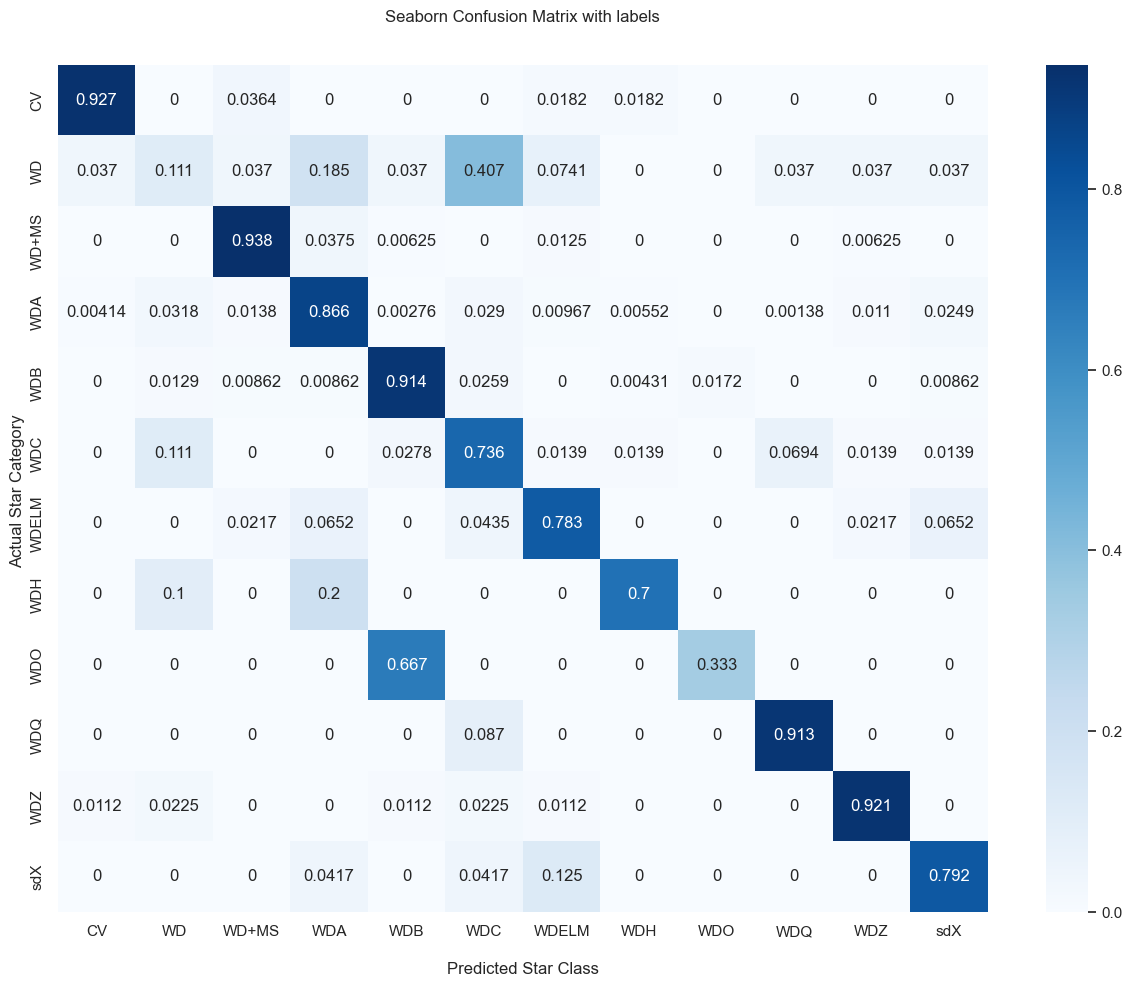

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc = {'figure.figsize':(15,11)})
ax = sns.heatmap(cf_matrix, annot=True, fmt='.3g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Star Class')
ax.set_ylabel('Actual Star Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()

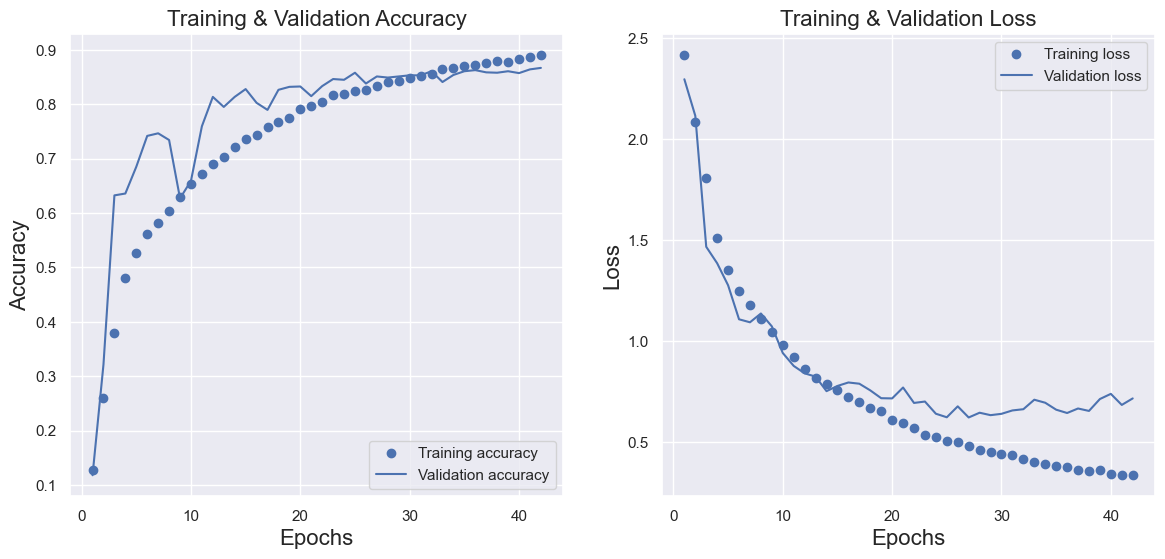

In [104]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
 
epochs = range(1, len(loss_values) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
#
# Plot the model accuracy vs Epochs
#
ax[0].plot(epochs, accuracy, 'bo', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'b', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()
#
# Plot the loss vs Epochs
#
ax[1].plot(epochs, loss_values, 'bo', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'b', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()